In [1]:
import lightkurve
import matplotlib.pyplot as plot
import numpy
import triceratops.triceratops as tr
import json

from lightkurve.correctors import PLDCorrector

%matplotlib inline
# plot.style.use('seaborn-v0_8')
parent_folder = 'CTOI Creation'

In [2]:
data_paths = []

with open(f'{parent_folder}/queue_data_paths.txt', 'r+') as file:
    data_paths.extend([file_name.strip() for file_name in file.readlines()])
    file.seek(0)

data_paths

['CTOI Creation/Candidates/TIC 451483379/save_data/TIC 451483379 b @ 2025-July-31 10:58:56 AM.json']

In [3]:
data_path = data_paths[0]
data_path

'CTOI Creation/Candidates/TIC 451483379/save_data/TIC 451483379 b @ 2025-July-31 10:58:56 AM.json'

In [4]:
with open(data_path, 'r') as file:
    data = json.load(file)

data

{'exoplanet_num': 1,
 'flux_unc': 0.0010972081756470255,
 'host_star': {'name': 'TIC 451483379'},
 'id_num': 451483379,
 'letter': 'b',
 'name': 'TIC 451483379 b',
 'parameters': {},
 'period': 22.12811880336694,
 'period_fwhm': 37.45000876944273,
 'period_unc': 18.725004384721366,
 'signal_to_noise_ratio': 10.751177890506575,
 'transit_depth': 0.02780395746231079,
 'transit_depth_unc': 0.0012663767337998929,
 'transit_duration': 7.958156646442886,
 'transit_duration_unc': 0.7402125355464574,
 'transit_time': 1589.1340776657307,
 'transit_time_unc': 0.03084218898110239,
 'triceratops': {'period': 22.12811880336694,
  'transit_depth': 0.02780395746231079,
  'transit_duration': 7.958156646442886,
  'transit_time': 1589.1340776657307}}

In [5]:
# data = {
#     'id_num': 235060821,
#     'triceratops': {
#         'period': None,
#         'transit_duration': 14,
#         'transit_time': 1507.5,
#         'transit_depth': 0.0004
#     }
# }

In [6]:
star_id = data['id_num']
star_id

451483379

In [7]:
triceratops = data['triceratops']
triceratops

{'period': 22.12811880336694,
 'transit_depth': 0.02780395746231079,
 'transit_duration': 7.958156646442886,
 'transit_time': 1589.1340776657307}

In [8]:
search_result = lightkurve.search_lightcurve(f'TIC {star_id}', mission = 'TESS')[:20]
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 64,2023,SPOC,120,451483379,0.0
1,TESS Sector 90,2025,SPOC,120,451483379,0.0
2,TESS Sector 10,2019,TESS-SPOC,1800,451483379,0.0
3,TESS Sector 37,2021,TESS-SPOC,600,451483379,0.0
4,TESS Sector 64,2023,TESS-SPOC,200,451483379,0.0
5,TESS Sector 10,2019,QLP,1800,451483379,0.0
6,TESS Sector 37,2021,QLP,600,451483379,0.0
7,TESS Sector 64,2023,QLP,200,451483379,0.0
8,TESS Sector 90,2025,QLP,200,451483379,0.0


In [9]:
lc = search_result[4].download_all().stitch().normalize()
lc

time,flux,flux_err,timecorr,cadenceno,centroid_col,centroid_row,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,,,d,,pix,pix,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,float32,int32,float64,float64,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
3041.1203128074767,9.9901617e-01,1.0994722e-03,3.5746465e-03,783500,1351.28842,646.63298,1.1072051e+04,1.0505862e+01,2.4768118e+03,4.0423393e+00,1.1371222e+04,1.2514654e+01,0,———,———,———,———,1351.28842,7.2383863e-04,646.63298,7.5405743e-04,1.9683830e-02,2.8531129e-02
3041.1226276431225,1.0022191e+00,1.0997031e-03,3.5746684e-03,783501,1351.28905,646.63359,1.1102654e+04,1.0508069e+01,2.4636660e+03,4.0352960e+00,1.1407679e+04,1.2517283e+01,0,———,———,———,———,1351.28905,7.2162476e-04,646.63359,7.5205450e-04,2.0234110e-02,3.1732820e-02
3041.1249424785346,9.9964911e-01,1.0999807e-03,3.5746901e-03,783502,1351.28965,646.63116,1.1079596e+04,1.0510721e+01,2.4698054e+03,4.0491233e+00,1.1378426e+04,1.2520442e+01,0,———,———,———,———,1351.28965,7.2386482e-04,646.63116,7.5383973e-04,1.8815698e-02,2.7615072e-02
3041.1272573139477,9.9950159e-01,1.0991776e-03,3.5747117e-03,783503,1351.29004,646.63195,1.1078252e+04,1.0503048e+01,2.4682983e+03,4.0381141e+00,1.1376747e+04,1.2511302e+01,0,———,———,———,———,1351.29004,7.2272803e-04,646.63195,7.5342198e-04,2.0686546e-02,3.0201586e-02
3041.1295721495926,1.0008043e+00,1.0990453e-03,3.5747336e-03,783504,1351.28956,646.63103,1.1091277e+04,1.0501783e+01,2.4580603e+03,4.0337286e+00,1.1391574e+04,1.2509795e+01,0,———,———,———,———,1351.28956,7.2202767e-04,646.63103,7.5264595e-04,1.9938329e-02,2.7670054e-02
3041.1318869850056,1.0000039e+00,1.0994349e-03,3.5747553e-03,783505,1351.28998,646.63445,1.1079871e+04,1.0505506e+01,2.4672805e+03,4.0379753e+00,1.1382465e+04,1.2514230e+01,0,———,———,———,———,1351.28998,7.2292809e-04,646.63445,7.5350679e-04,2.1854445e-02,3.3321183e-02
3041.1342018206506,1.0015444e+00,1.0996230e-03,3.5747772e-03,783506,1351.28906,646.63197,1.1100150e+04,1.0507303e+01,2.4628557e+03,4.0353365e+00,1.1399998e+04,1.2516371e+01,0,———,———,———,———,1351.28906,7.2183163e-04,646.63197,7.5257587e-04,1.9141315e-02,2.6200453e-02
3041.1365166560636,9.9982077e-01,1.0987406e-03,3.5747988e-03,783507,1351.29023,646.63537,1.1080104e+04,1.0498872e+01,2.4621931e+03,4.0332146e+00,1.1380380e+04,1.2506328e+01,0,———,———,———,———,1351.29023,7.2258734e-04,646.63537,7.5353193e-04,2.1343427e-02,3.1430405e-02


In [20]:
period = triceratops['period']
duration = triceratops['transit_duration'] / 24
transit_time = triceratops['transit_time']
depth = triceratops['transit_depth']
sectors = [64]
exptime = 200 / 86400

In [11]:
# import pandas

# url = 'https://stev.oapd.inaf.it/tmp/output603559110852.dat'

# data = pandas.read_csv('trilegal.tbl', delim_whitespace = True, comment = '#')
# data

In [12]:
# data.to_csv('trilegal.csv')

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

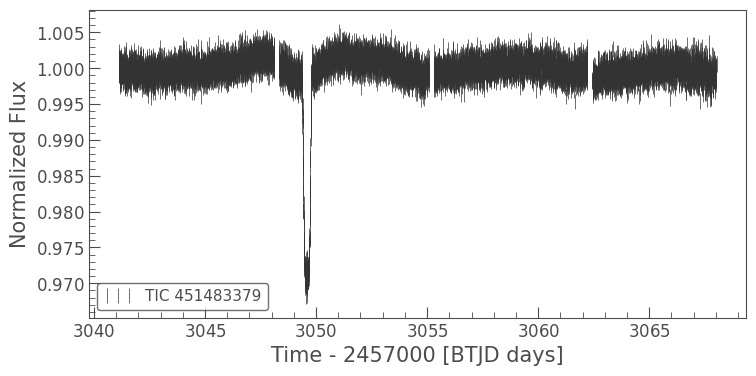

In [13]:
lc.errorbar()

In [14]:
# depth += -0.005 # add extra depth after seeing folded to improve value

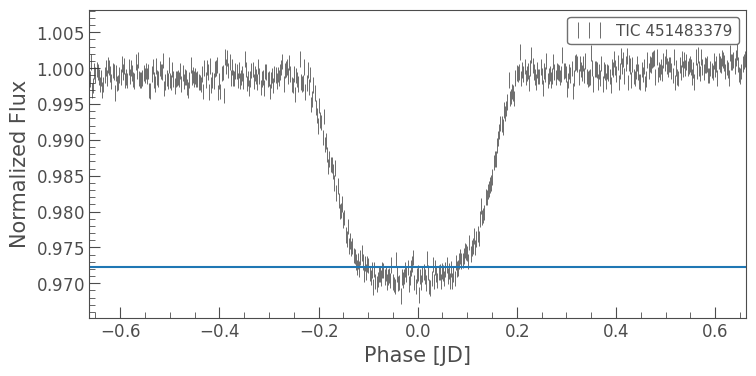

In [15]:
lc = lc.normalize()
period = period if period is not None else 100
flc = lc.fold(period = period, epoch_time = transit_time)
flc.errorbar()
plot.hlines([1 - depth], flc.time.min().value, flc.time.max().value)
plot.xlim(-duration * 2, duration * 2)
plot.show()

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

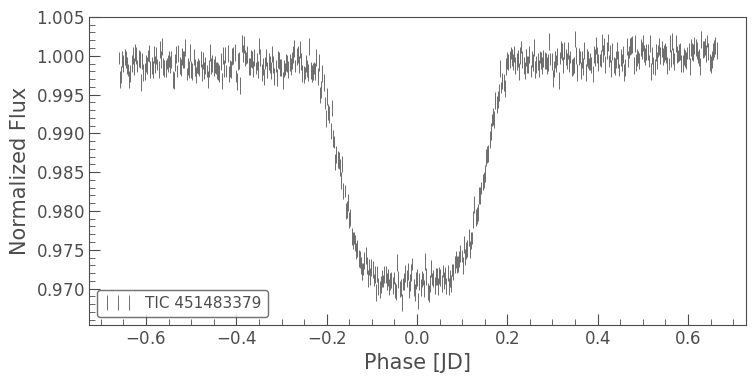

In [16]:
mask = numpy.abs(flc.time) < duration * 2
mflc = flc[mask]
blc = mflc.bin(time_bin_size = (2 * duration * 2) / 512)
blc.errorbar()

In [21]:
target = tr.target(ID = star_id, search_radius = 5, sectors = numpy.array(sectors), trilegal_fname = None)

Getting TessCut for sector 64


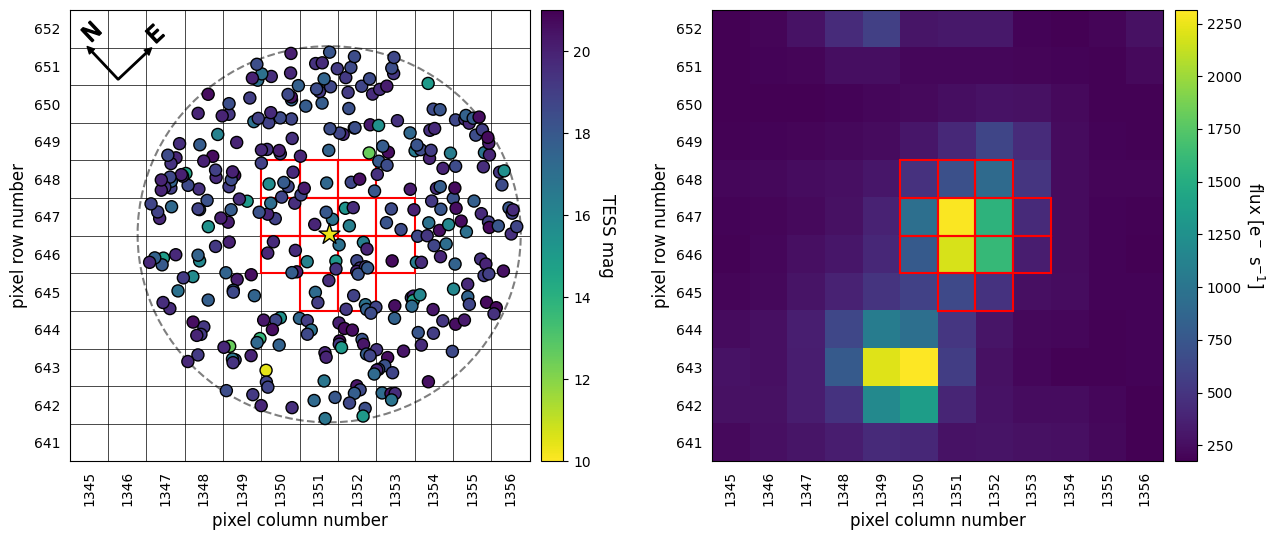

In [23]:
aps = target.get_spoc_apertures()
target.plot_field(sector = sectors[0], ap_pixels = None if aps == [] else aps[0], ap_color = 'red')

In [24]:
target.stars

,ID,Tmag,Jmag,Hmag,Kmag,ra,dec,mass,rad,Teff,plx,sep (arcsec),PA (E of N)
0,451483379,10.3044,9.720,9.478,9.399,171.591540,-55.072056,1.41,4.210840,6670.0,1.343980,0.000,0.000
1,451483366,16.9810,16.481,14.727,14.948,171.591483,-55.074261,NaN,NaN,NaN,NaN,7.940,180.842
2,451483386,16.9474,15.283,14.770,14.538,171.594830,-55.070754,0.71,1.453350,4505.0,0.438603,8.244,55.345
3,932832607,19.8531,NaN,NaN,NaN,171.590609,-55.069462,NaN,NaN,NaN,0.902954,9.533,348.389
4,451483370,16.3067,15.298,14.783,14.665,171.596810,-55.073238,0.87,0.919908,5159.0,0.660782,11.667,111.406
...,...,...,...,...,...,...,...,...,...,...,...,...,...
330,932831134,18.6357,NaN,NaN,NaN,171.635191,-55.059473,NaN,NaN,5607.0,0.635620,100.746,63.298
331,451483289,18.6944,16.587,15.895,15.429,171.627840,-55.090846,NaN,NaN,NaN,NaN,100.855,132.138
332,932832692,20.6460,NaN,NaN,NaN,171.594029,-55.044067,NaN,NaN,NaN,NaN,100.890,2.917
333,932832699,19.7586,NaN,NaN,NaN,171.542476,-55.071189,NaN,NaN,NaN,-0.453498,101.177,271.747


In [25]:
target.calc_depths(tdepth = depth, all_ap_pixels = aps)

In [26]:
target.stars[target.stars.tdepth > 0]

,ID,Tmag,Jmag,Hmag,Kmag,ra,dec,mass,rad,Teff,plx,sep (arcsec),PA (E of N),fluxratio,tdepth
0,451483379,10.3044,9.720,9.478,9.399,171.591540,-55.072056,1.41,4.21084,6670.0,1.343980,0.00,0.000,0.898735,0.030937
64,451483398,12.4939,10.932,10.162,9.881,171.613513,-55.067333,NaN,27.08130,4263.0,0.196328,48.38,69.433,0.031761,0.875421


In [27]:
target.calc_probs(
    time = blc.time.value,                               # binned time data
    flux_0 = blc.flux.value,                             # binned flux data
    flux_err_0 = numpy.mean(blc.flux_err.value),            # standard deviation of (out-of-transit) flux data
    P_orb = period,                              # best-fit orbital period of planet candidate
    contrast_curve_file = None,        # contrast curve file to use (str)
    filt = 'TESS',                                # number of instances to simulate for each scenario (int, usually fine to leave alone)
    parallel = True,                               # whether or not to use parallel processing (bool)
    # drop_scenario = ['DTP', 'DEB', 'DEBx2P', 'BTP', 'BEB', 'BEBx2P', 'NTP', 'NEB', 'NEB2xP'],
    verbose = 1,                                   # whether or not to print updates (0 or 1)
    flatpriors = False,                            # whether or not to assume flat planet priors (bool)
    exptime = exptime,                             # exposure time of TESS data (float, in days)
    molusc_file = None
)

Calculating TP scenario probabilitiey for 451483379.
Calculating EB and EBx2P scenario probabilities for 451483379.
Calculating PTP scenario probability for 451483379.
Calculating PEB and PEBx2P scenario probabilities for 451483379.
Calculating STP scenario probability for 451483379.
Calculating SEB and SEBx2P scenario probabilities for 451483379.
Calculating DTP scenario probability for 451483379.
Calculating DEB and DEBx2P scenario probabilities for 451483379.
Calculating BTP scenario probability for 451483379.
Calculating BEB and BEBx2P scenario probabilities for 451483379.
Calculating NTP, NEB, and NEB2xP scenario probabilities for 451483398.


In [28]:
target.probs

,ID,scenario,M_s,R_s,P_orb,inc,b,ecc,w,R_p,M_EB,R_EB,prob
0,451483379,TP,1.410000,4.210840,22.128119,89.558733,0.063324,0.069162,88.203794,19.992170,0.000000,0.000000,0.000000e+00
1,451483379,EB,1.410000,4.210840,22.128119,76.891117,1.316658,0.635835,11.704786,0.000000,1.314829,1.464081,0.000000e+00
2,451483379,EBx2P,1.410000,4.210840,44.256238,83.630718,0.642253,0.673367,78.562305,0.000000,1.370425,1.520262,9.412380e-64
3,451483379,PTP,1.410000,4.210840,22.128119,89.583181,0.064268,0.004072,182.414126,19.995327,0.000000,0.000000,0.000000e+00
4,451483379,PEB,1.410000,4.210840,22.128119,76.501712,1.142664,0.698497,12.098997,0.000000,1.282855,1.431161,0.000000e+00
5,451483379,PEBx2P,1.410000,4.210840,44.256238,84.038739,0.790364,0.583285,62.809970,0.000000,1.340189,1.489815,4.509328e-60
6,451483379,STP,1.388440,1.538368,22.128119,89.351784,0.188632,0.638351,193.150346,19.692261,0.000000,0.000000,0.000000e+00
7,451483379,SEB,1.334363,1.483924,22.128119,89.655227,0.184672,0.486726,223.793409,0.000000,0.364335,0.371967,1.000000e+00
8,451483379,SEBx2P,1.031053,1.124406,44.256238,89.119892,0.721090,0.376322,166.873521,0.000000,1.006413,1.088634,2.384059e-178
9,451483379,DTP,1.410000,4.210840,22.128119,89.797965,0.034795,0.175617,311.034924,19.984459,0.000000,0.000000,0.000000e+00


In [29]:
print('FPP = ', target.FPP) # eb on this star, etc.
print('NFPP = ', target.NFPP) # nearby contamination

FPP =  1.0
NFPP =  0.0


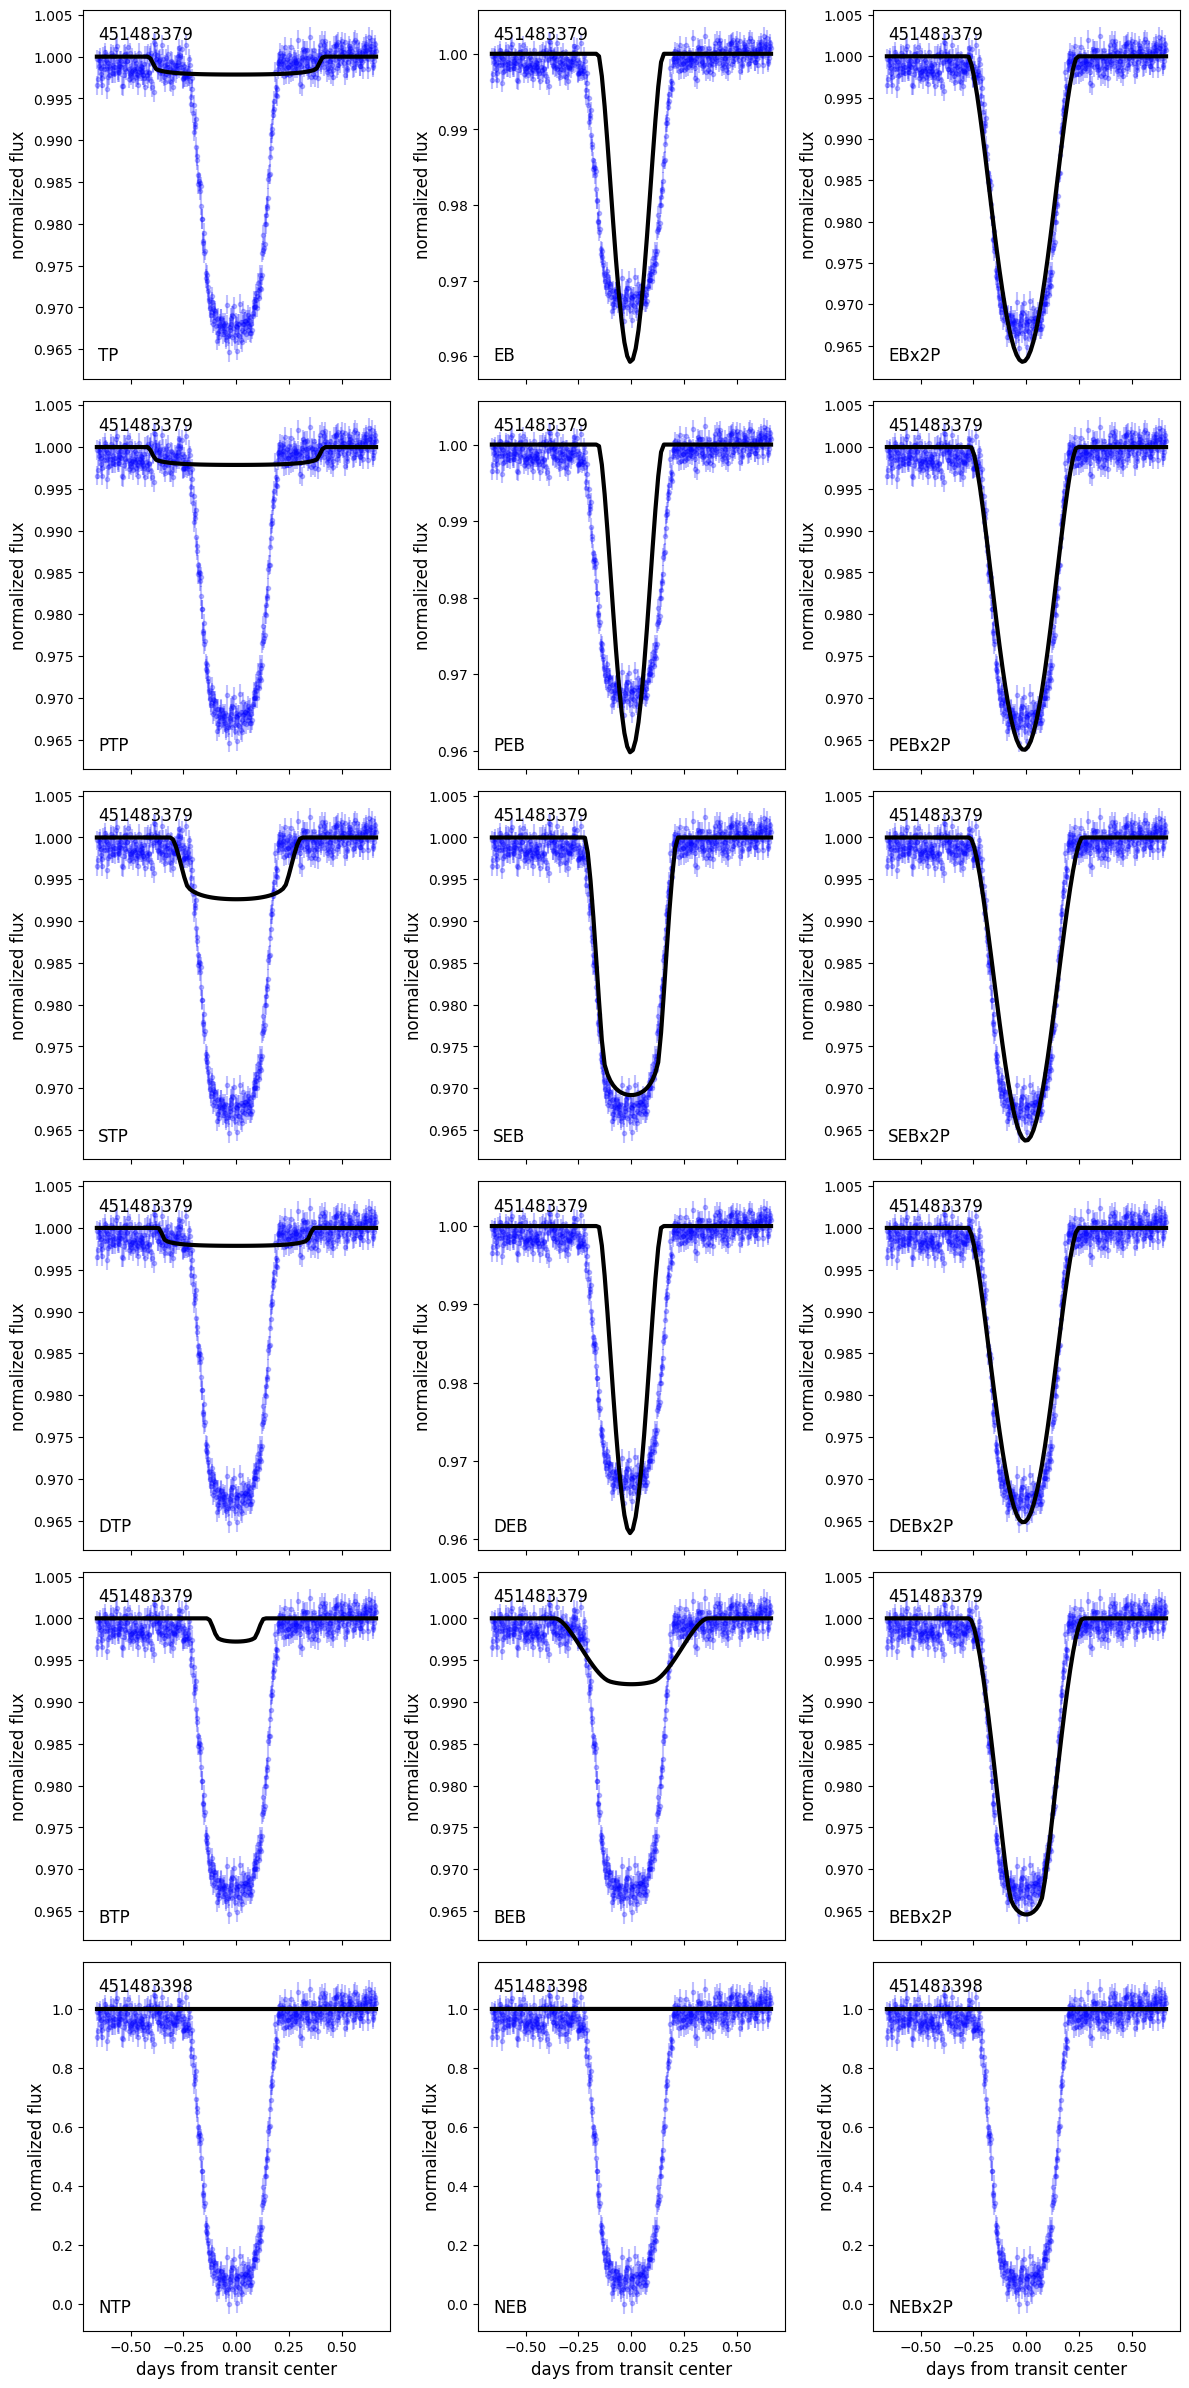

In [30]:
target.plot_fits(
    time = blc.time.value,                               # binned time data
    flux_0 = blc.flux.value,                             # binned flux data
    flux_err_0 = numpy.mean(blc.flux_err.value)
)